In [27]:
from pathlib import Path
from multiprocessing import Pool, cpu_count
from functools import partial

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.cluster import KMeans

In [28]:
DATA_PATH = Path("./data")
SPOTIFY_DATA_PATH = DATA_PATH / "spotify_songs.parquet"

In [29]:
RANDOM_STATE = 42
N_CLUSTERS = 6

In [30]:
spotify_df = pd.read_parquet(SPOTIFY_DATA_PATH)
spotify_df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [31]:
spotify_df["track_album_release_date"] = pd.to_datetime(spotify_df["track_album_release_date"], errors='coerce')
spotify_df["track_album_release_year"] = spotify_df["track_album_release_date"].dt.year
spotify_df["track_album_release_month"] = spotify_df["track_album_release_date"].dt.month

In [32]:
len(spotify_df.playlist_name.unique()), len(spotify_df.playlist_id.unique()), len(spotify_df.track_id.unique())

(449, 471, 28356)

In [33]:
def convert_to_numerical_id(data: pd.Series) -> pd.Series:
    """
    Convert a pandas Series of IDs to numerical values.
    """
    return pd.factorize(data)[0]

In [34]:
spotify_df["playlist_id"] = convert_to_numerical_id(spotify_df["playlist_id"])
spotify_df["track_id"] = convert_to_numerical_id(spotify_df["track_id"])
spotify_df["track_artist"] = convert_to_numerical_id(spotify_df["track_artist"])
spotify_df["track_album_id"] = convert_to_numerical_id(spotify_df["track_album_id"])

In [35]:
categorical_cols = [
    "playlist_genre",
    "playlist_subgenre",
    "track_album_release_year",
    "track_album_release_month"
]

sdf_categorized = pd.get_dummies(spotify_df, columns=categorical_cols, drop_first=True, dtype="int64")
sdf_categorized

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,danceability,...,track_album_release_month_3.0,track_album_release_month_4.0,track_album_release_month_5.0,track_album_release_month_6.0,track_album_release_month_7.0,track_album_release_month_8.0,track_album_release_month_9.0,track_album_release_month_10.0,track_album_release_month_11.0,track_album_release_month_12.0
0,0,I Don't Care (with Justin Bieber) - Loud Luxur...,0,66,0,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,0,0.748,...,0,0,0,1,0,0,0,0,0,0
1,1,Memories - Dillon Francis Remix,1,67,1,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,0,0.726,...,0,0,0,0,0,0,0,0,0,1
2,2,All the Time - Don Diablo Remix,2,70,2,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,0,0.675,...,0,0,0,0,1,0,0,0,0,0
3,3,Call You Mine - Keanu Silva Remix,3,60,3,Call You Mine - The Remixes,2019-07-19,Pop Remix,0,0.718,...,0,0,0,0,1,0,0,0,0,0
4,4,Someone You Loved - Future Humans Remix,4,69,4,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,0,0.650,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,28351,City Of Lights - Official Radio Edit,183,42,22540,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,470,0.428,...,0,1,0,0,0,0,0,0,0,0
32829,28352,Closer - Sultan & Ned Shepard Remix,10690,20,22541,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,470,0.522,...,1,0,0,0,0,0,0,0,0,0
32830,28353,Sweet Surrender - Radio Edit,9770,14,22542,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,470,0.529,...,0,1,0,0,0,0,0,0,0,0
32831,28354,Only For You - Maor Levi Remix,10691,15,22543,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,470,0.626,...,0,0,0,0,0,0,0,0,0,0


In [36]:
drop_cols = [
    "track_id",
    "playlist_id",
    "playlist_name",
    "track_name",
    "track_album_name",
    "playlist_name",
    "track_album_release_date",
]

X = sdf_categorized.drop(columns=drop_cols, errors='ignore')
X 

,track_artist,track_popularity,track_album_id,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_album_release_month_3.0,track_album_release_month_4.0,track_album_release_month_5.0,track_album_release_month_6.0,track_album_release_month_7.0,track_album_release_month_8.0,track_album_release_month_9.0,track_album_release_month_10.0,track_album_release_month_11.0,track_album_release_month_12.0
0,0,66,0,0.748,0.916,6,-2.634,1,0.0583,0.102000,...,0,0,0,1,0,0,0,0,0,0
1,1,67,1,0.726,0.815,11,-4.969,1,0.0373,0.072400,...,0,0,0,0,0,0,0,0,0,1
2,2,70,2,0.675,0.931,1,-3.432,0,0.0742,0.079400,...,0,0,0,0,1,0,0,0,0,0
3,3,60,3,0.718,0.930,7,-3.778,1,0.1020,0.028700,...,0,0,0,0,1,0,0,0,0,0
4,4,69,4,0.650,0.833,1,-4.672,1,0.0359,0.080300,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,183,42,22540,0.428,0.922,2,-1.814,1,0.0936,0.076600,...,0,1,0,0,0,0,0,0,0,0
32829,10690,20,22541,0.522,0.786,0,-4.462,1,0.0420,0.001710,...,1,0,0,0,0,0,0,0,0,0
32830,9770,14,22542,0.529,0.821,6,-4.899,0,0.0481,0.108000,...,0,1,0,0,0,0,0,0,0,0
32831,10691,15,22543,0.626,0.888,2,-3.361,1,0.1090,0.007920,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# model = KMeans(random_state=RANDOM_STATE)
# visualizer = KElbowVisualizer(model, k=(4, 12))
# visualizer.fit(X)
# visualizer.show()

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
def run_model(model, X):
    return model.fit(X).inertia_

def k_elbow_visualizer(X, k=(4, 12), random_state=RANDOM_STATE):
    """
    Create a KElbowVisualizer for the given data.
    """
    models = [
        KMeans(n_clusters=n, random_state=random_state) for n in range(k[0], k[1] + 1)
    ]

    res = [
        run_model(model, X) for model in models
    ]

    plt.figure(figsize=(10, 6))
    plt.plot(range(k[0], k[1] + 1), res, marker="o")
    plt.title("KElbowVisualizer")
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.xticks(range(k[0], k[1] + 1))
    plt.grid()
    plt.show()

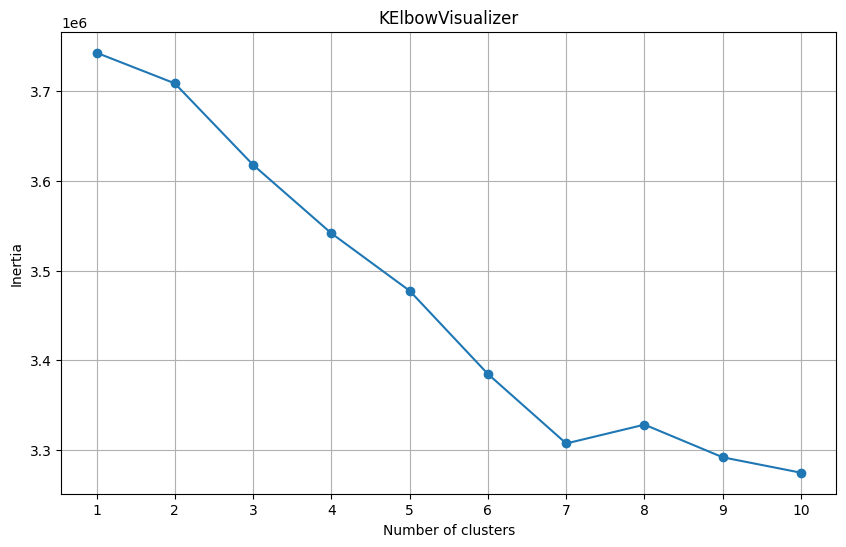

In [40]:
k_elbow_visualizer(X_scaled, k=(1, 10), random_state=RANDOM_STATE)

In [41]:
N_CLUSTERS = 7

In [42]:
pipeline = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
)
labels = pipeline.fit_predict(X)
labels

array([2, 2, 2, ..., 4, 4, 4], shape=(32833,), dtype=int32)

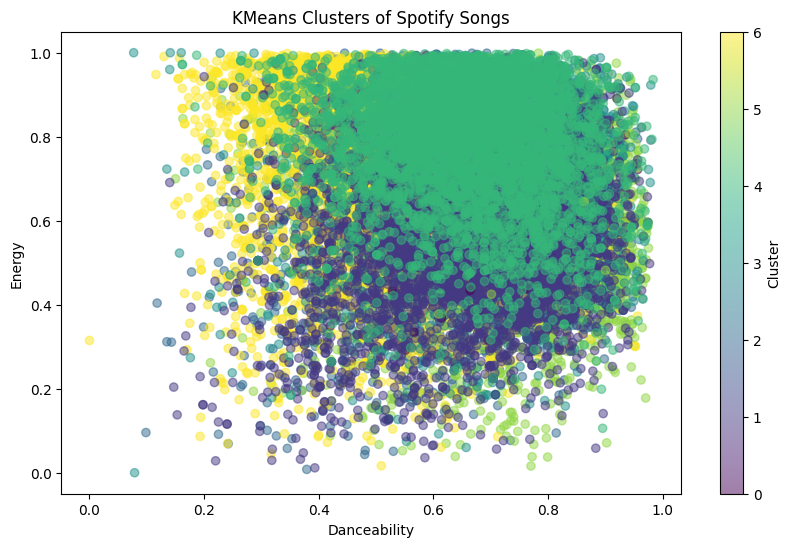

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(
    spotify_df['danceability'],
    spotify_df['energy'],
    c=labels,
    cmap='viridis',
    alpha=0.5
)
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.title('KMeans Clusters of Spotify Songs')
plt.colorbar(label='Cluster')
plt.show()

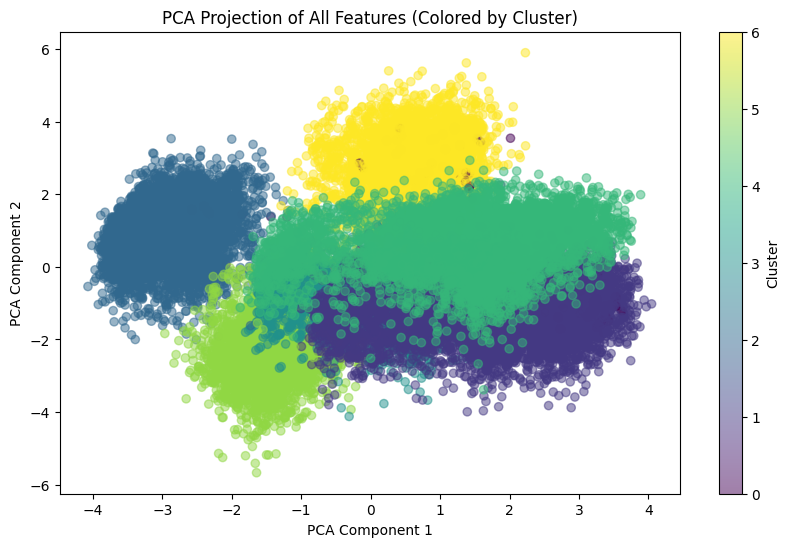

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Projection of All Features (Colored by Cluster)')
plt.colorbar(label='Cluster')
plt.show()

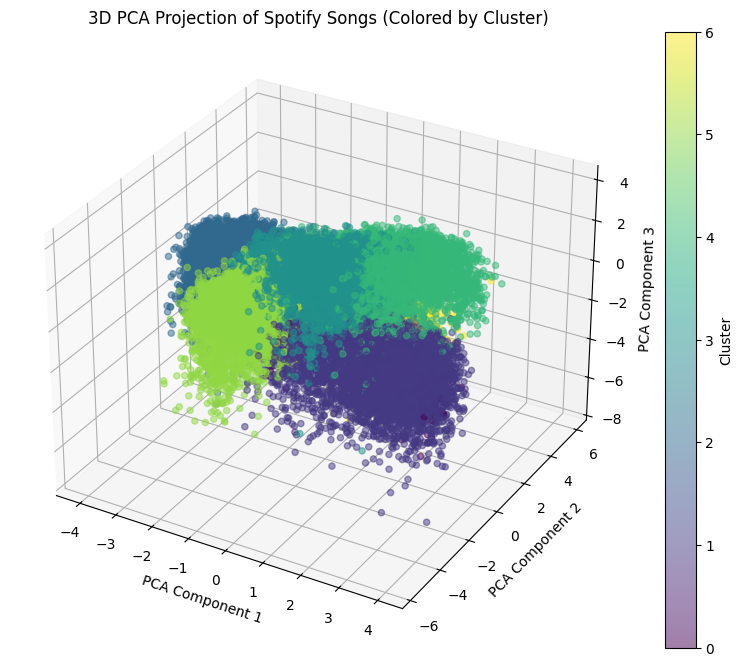

In [45]:
from mpl_toolkits.mplot3d import Axes3D

# Compute 3D PCA projection
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=labels,
    cmap='viridis',
    alpha=0.5
)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA Projection of Spotify Songs (Colored by Cluster)')
fig.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

In [46]:

fig = px.scatter_3d(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    color=labels,
    labels={'x': 'PCA Component 1', 'y': 'PCA Component 2', 'z': 'PCA Component 3'},
    title='3D PCA Projection of Spotify Songs (Colored by Cluster)',
    opacity=0.5,
    color_continuous_scale='viridis',
    height=900
)
fig.show()